In [1]:
import numpy as np
from scipy.stats import norm, kurtosis, combine_pvalues, lognorm
from scipy.stats import t as studt
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox

In [2]:
# define params
lambda_ = 0.1
b = 2
k_bar = 15
sigma_bar = 0.01
gamma_k_bar = 0.5
n = 5_000
S0 = 10
npaths = 400

In [5]:
def get_gammas(k_bar, gamma_k_bar, b):
    '''
    This function gets the gamma renewal probabilitie from the gamma k bar param.
    '''

    gammas = np.zeros(k_bar)
    gammas[-1] = gamma_k_bar
    for i in range(k_bar - 1, 0, -1):
        gammas[i-1] = 1 - (1 - gamma_k_bar) ** (b ** ((i - k_bar)))
                                                
    return gammas                 

def renew_multipliers(gammas, lambda_, M_t):
    '''
    This function does the renewal/keep previous calculation based on binomial dist.
    '''
    
    M_t_1 = np.zeros(len(gammas))

    for i in range(len(gammas)):
        curr_gam = gammas[i]

        if np.random.rand() <= curr_gam:
            sd = np.sqrt(2*lambda_)
            new_draw = lognorm.rvs(scale = np.exp(-lambda_), s = sd, size = 1)
            M_t_1[i] = new_draw
        else:
            M_t_1[i] = M_t[i]

    return M_t_1

def initial_multipliers(k_bar, lambda_):
    '''
    This function computes the initial multipliers to start of the simulation. 
    '''

    M_0 = np.zeros(k_bar)
    sd = np.sqrt(2 * lambda_)

    for i in range(k_bar):
        M_0[i] = lognorm.rvs(scale = np.exp(-lambda_), s = sd, size = 1)

    return M_0

def simulate_msm(lambda_, n, b, k_bar, sigma_bar, gamma_k_bar, S0):

    r_t = np.zeros(n)
    logS = np.zeros(n)
    logS[0] = np.log(S0)
    sigma2_t = np.zeros(n)

    M_0 = initial_multipliers(k_bar, lambda_)
    gammas = get_gammas(k_bar, gamma_k_bar, b)
    
    sigma2_t[0] = sigma_bar ** 2 * np.prod(M_0)
    innovation_0 = norm.rvs()
    r_t[0] = np.sqrt(sigma2_t[0]) * innovation_0
    M_t = M_0

    for t in range(1, n):
    
        M_t = renew_multipliers(gammas, lambda_, M_t)
        sigma2_t[t] = sigma_bar ** 2 * np.prod(M_t)
        innovation_t = norm.rvs()
        r_t[t] = np.sqrt(sigma2_t[t]) * innovation_t
        logS[t] = logS[t-1] - 0.5 * sigma2_t[t] + r_t[t] # remove bias 

    S_t = np.exp(logS)

    return r_t, sigma2_t, S_t


In [6]:
r = np.zeros((n, npaths))
h = np.zeros((n, npaths))
S = np.zeros((n, npaths))

for i in range(npaths):
    r[:, i], h[:, i], S[:, i] = simulate_msm(lambda_, n, b, k_bar, sigma_bar, gamma_k_bar, S0)

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_52172/989823493.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  M_0[i] = lognorm.rvs(scale = np.exp(-lambda_), s = sd, size = 1)
/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_52172/989823493.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  M_t_1[i] = new_draw


In [7]:
np.savez("all_paths_Lmsm_lamb_0.1.npz", r=r, h=h, S=S)

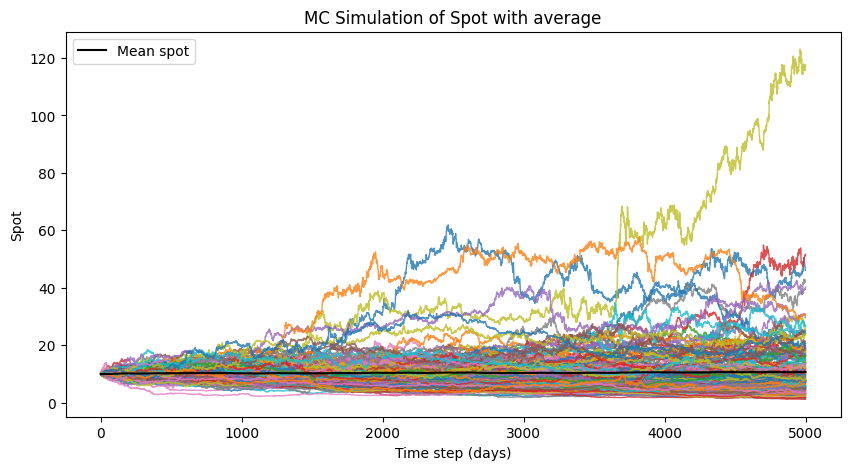

In [179]:
plt.figure(figsize=(10, 5))
for k in range(8, 190):
    plt.plot(S[:, k], linewidth = 1, alpha = 0.8)

mean_spot = np.mean(S, axis = 1)
plt.plot(mean_spot, "-", color = 'k', label = "Mean spot")
plt.xlabel("Time step (days)")
plt.ylabel("Spot")
plt.title("MC Simulation of Spot with average")
plt.legend()

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_40499/2846948158.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


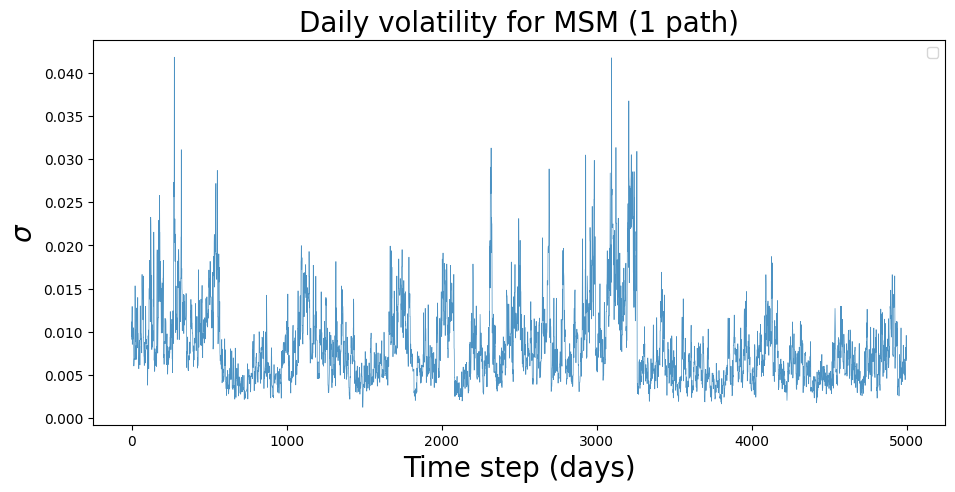

In [181]:
plt.figure(figsize=(11, 5))
plt.plot(np.sqrt(h[1:, 0]), linewidth = 0.5, alpha = 0.8, color = 'tab:blue')
plt.xlabel("Time step (days)", fontsize = 20)
plt.ylabel(r"$\sigma$", fontsize = 20)
plt.title("Daily volatility for MSM (1 path)", fontsize = 20)
#plt.savefig("/Users/alexvillamartin/Documents/MSc Diss/Plots/daily_vol_msm")
plt.legend()